# Processing Agent — Aurora

**Input:** FNSPID headlines (HuggingFace) + yfinance closing prices  
**Output:** `processed_data.csv` — one row per article with date, ticker, headline, prices T and T+1, percentage change, and label (up/down/neutral)

This notebook also contains the EDA section for the June 15 checkpoint presentation.

Data contract: see `data_contracts.md` → Handoff 1

In [43]:
# Uncomment and run if packages are not installed (e.g. on Google Colab)
!pip install datasets yfinance pandas matplotlib seaborn torch torchvision transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.0 MB/s eta 0:00:00a 0:00:01


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datasets import load_dataset
from collections import defaultdict
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## Configuration

All parameters in one place — change here, not inside the functions.

In [3]:
TOP_N_TICKERS       = 30      # final number of working tickers in the dataset
TICKER_POOL         = 50      # candidates to discover — buffer covers delisted / renamed tickers
ARTICLES_PER_TICKER = 500     # articles to sample per ticker
COUNT_CAP           = 10_000_000  # row limit for the counting pass (reads fast — no storage)
LOAD_CAP            = 3_000_000   # row limit for the loading pass
LABEL_THRESHOLD     = 0.01    # ±1% → up / down / neutral

print(f'Will discover top {TICKER_POOL} candidates, screen for price data, keep {TOP_N_TICKERS} working tickers')
print(f'Target dataset size: ~{TOP_N_TICKERS * ARTICLES_PER_TICKER:,} rows')

Will discover top 50 candidates, screen for price data, keep 30 working tickers
Target dataset size: ~15,000 rows


### Shortcut — skip streaming if already loaded

If `fnspid_raw.csv` exists, run the cell below and jump straight to **Section 2**. No need to re-run Section 1.

In [4]:
if os.path.exists('fnspid_raw.csv'):
    df = pd.read_csv('fnspid_raw.csv')
    top_tickers = sorted(df['ticker'].unique().tolist())
    print(f'Loaded fnspid_raw.csv: {len(df):,} rows, {len(top_tickers)} tickers')
    print('Section 1 can be skipped — jump to Section 2.')
else:
    print('fnspid_raw.csv not found — run Section 1 to stream from HuggingFace.')

fnspid_raw.csv not found — run Section 1 to stream from HuggingFace.


## Section 1 — Load FNSPID

Three-step approach — discovers popular tickers, screens for live price data, then loads articles only for confirmed working tickers.

- **Pass 1 (fast):** streams the full dataset reading only `Stock_symbol`. No row storage — just counting. Discovers the top `TICKER_POOL` (50) candidates by article volume.
- **Price screen:** quick yfinance check on each candidate to identify delisted, merged, or renamed tickers. Keeps the first `TOP_N_TICKERS` (30) that return data. **Zero articles are wasted** on tickers with no price data.
- **Pass 2:** streams again and samples `ARTICLES_PER_TICKER` rows from each of the 30 confirmed working tickers.

This replaces the old approach where the top 30 were loaded first and 7 failed at the price step (DISH, FCAU, GMCR, JWN, MYL, VMW, YHOO — all delisted, merged, or taken private).

In [5]:
def count_tickers(cap):
    """Pass 1: count articles per ticker across the full dataset. Fast — no row storage.
    Returns (counts dict, total_rows, hit_cap).
    If hit_cap is False, total_rows is the exact dataset size.
    """
    ds = load_dataset('Zihan1004/FNSPID', streaming=True, split='train')
    counts = defaultdict(int)
    total_rows = 0
    for i, row in enumerate(ds):
        total_rows = i + 1
        symbol = row.get('Stock_symbol', '')
        if symbol:
            counts[symbol] += 1
        if i >= cap:
            print(f'Count cap reached at {i:,} rows — dataset has more rows than cap')
            return counts, total_rows, True
        if i % 500_000 == 0 and i > 0:
            print(f'  {i:,} rows scanned — {len(counts):,} unique tickers seen so far')
    print(f'Reached end of dataset at {total_rows:,} rows — this is the exact dataset size')
    return counts, total_rows, False


print('Pass 1: counting articles per ticker...')
all_counts, total_rows, hit_cap = count_tickers(COUNT_CAP)

print(f'\n{"=" * 40}')
if hit_cap:
    print(f'Dataset size: > {COUNT_CAP:,} rows (cap hit — true size unknown)')
else:
    print(f'Dataset size: exactly {total_rows:,} rows')
print(f'Unique tickers found: {len(all_counts):,}')
print(f'{"=" * 40}')

ticker_series     = pd.Series(all_counts).sort_values(ascending=False)
candidate_tickers = list(ticker_series.head(TICKER_POOL).index)

print(f'\nTop {TICKER_POOL} candidate tickers (before price screen):')
print(ticker_series.head(TICKER_POOL).to_string())

Pass 1: counting articles per ticker...


Repo card metadata block was not found. Setting CardData to empty.


  500,000 rows scanned — 2,108 unique tickers seen so far
  1,000,000 rows scanned — 4,314 unique tickers seen so far
  1,500,000 rows scanned — 6,204 unique tickers seen so far
  2,000,000 rows scanned — 6,204 unique tickers seen so far
  2,500,000 rows scanned — 6,262 unique tickers seen so far
  3,000,000 rows scanned — 6,396 unique tickers seen so far
  3,500,000 rows scanned — 6,504 unique tickers seen so far
  4,000,000 rows scanned — 6,615 unique tickers seen so far
  4,500,000 rows scanned — 6,619 unique tickers seen so far
  5,000,000 rows scanned — 6,619 unique tickers seen so far
  5,500,000 rows scanned — 6,619 unique tickers seen so far
  6,000,000 rows scanned — 6,619 unique tickers seen so far
  6,500,000 rows scanned — 6,619 unique tickers seen so far
  7,000,000 rows scanned — 6,619 unique tickers seen so far
  7,500,000 rows scanned — 6,619 unique tickers seen so far
  8,000,000 rows scanned — 6,619 unique tickers seen so far
  8,500,000 rows scanned — 6,619 unique ti

In [6]:
def screen_tickers(candidates, sample_start, top_n):
    """Quick yfinance check: keep the first top_n candidates that return price data."""
    working, skipped = [], []
    for t in candidates:
        if len(working) >= top_n:
            break
        try:
            hist = yf.Ticker(t).history(
                start=sample_start,
                end=sample_start + pd.Timedelta(days=30),
                auto_adjust=False
            )
            if not hist.empty:
                working.append(t)
            else:
                skipped.append(t)
                print(f'  SKIP (no data)   {t}')
        except Exception as e:
            skipped.append(t)
            print(f'  SKIP (error)     {t}: {e}')
    print(f'\nSelected {len(working)} working tickers: {working}')
    if skipped:
        print(f'Skipped {len(skipped)} delisted / renamed / private: {skipped}')
    return working


# Use the start of FNSPID's date range so the screen matches the actual data window
SCREEN_DATE = pd.Timestamp('2012-06-01')

print(f'Screening {len(candidate_tickers)} candidates for yfinance data around {SCREEN_DATE.date()}...')
top_tickers = screen_tickers(candidate_tickers, SCREEN_DATE, TOP_N_TICKERS)

Screening 50 candidates for yfinance data around 2012-06-01...


$DISH: possibly delisted; no timezone found


  SKIP (no data)   DISH


$MYL: possibly delisted; no timezone found


  SKIP (no data)   MYL


...

  SKIP (no data)   GMCR


$DOW: possibly delisted; no price data found  (1d 2012-06-01 00:00:00 -> 2012-07-01 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1338523200, endDate = 1341115200")


  SKIP (no data)   DOW


$PANW: possibly delisted; no price data found  (1d 2012-06-01 00:00:00 -> 2012-07-01 00:00:00) (Yahoo error = "Data doesn't exist for startDate = 1338523200, endDate = 1341115200")


  SKIP (no data)   PANW

Selected 30 working tickers: ['KR', 'GILD', 'EWJ', 'MDT', 'HD', 'FDX', 'FCX', 'WDC', 'GRPN', 'AVGO', 'TWX', 'SLV', 'CSX', 'BLK', 'EA', 'TXN', 'TJX', 'OXY', 'KSS', 'AXP', 'CI', 'HAL', 'REGN', 'GME', 'PBR', 'LLY', 'TSN', 'SLB', 'STZ', 'AEO']
Skipped 9 delisted / renamed / private: ['DISH', 'MYL', 'JWN', 'FCAU', 'VMW', 'YHOO', 'GMCR', 'DOW', 'PANW']


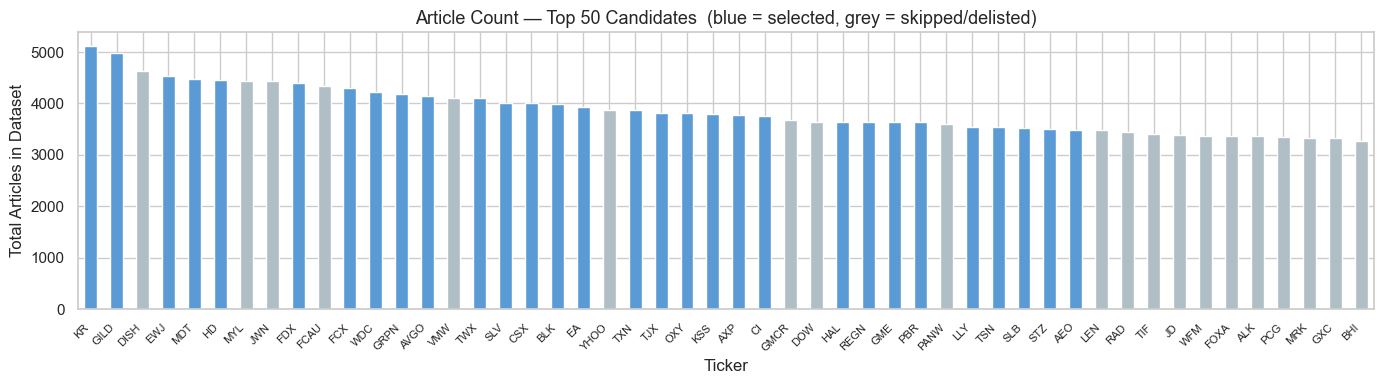

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
bar_colors = ['#5B9BD5' if t in top_tickers else '#B0BEC5' for t in candidate_tickers]
pd.Series(
    [ticker_series[t] for t in candidate_tickers],
    index=candidate_tickers
).plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title(
    f'Article Count — Top {TICKER_POOL} Candidates  (blue = selected, grey = skipped/delisted)',
    fontsize=13
)
ax.set_xlabel('Ticker')
ax.set_ylabel('Total Articles in Dataset')
ax.set_xticklabels(candidate_tickers, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('plots/ticker_coverage.png', dpi=150)
plt.show()

In [8]:
def load_fnspid_top(top_tickers, articles_per_ticker, cap):
    """Pass 2: sample articles from the discovered top tickers."""
    ds = load_dataset('Zihan1004/FNSPID', streaming=True, split='train')
    ticker_counts = defaultdict(int)
    rows = []
    target_set = set(top_tickers)

    for i, row in enumerate(ds):
        symbol = row.get('Stock_symbol', '')
        if symbol in target_set and ticker_counts[symbol] < articles_per_ticker:
            rows.append({
                'date':          row.get('Date', ''),
                'ticker':        symbol,
                'article_title': row.get('Article_title', '')
            })
            ticker_counts[symbol] += 1

        if all(ticker_counts[t] >= articles_per_ticker for t in top_tickers):
            print(f'All tickers reached quota at row {i:,}')
            break

        if i >= cap:
            print(f'Hit load cap ({cap:,} rows). Stopping.')
            break

        if i % 100_000 == 0 and i > 0:
            filled = sum(1 for t in top_tickers if ticker_counts[t] >= articles_per_ticker)
            print(f'  {i:,} rows scanned — {filled}/{len(top_tickers)} tickers complete')

    print(f'\nPer-ticker counts:')
    for t in top_tickers:
        print(f'  {t}: {ticker_counts[t]}')
    return rows


print('Pass 2: loading articles from top tickers...')
raw_rows = load_fnspid_top(top_tickers, ARTICLES_PER_TICKER, LOAD_CAP)
print(f'\nTotal rows loaded: {len(raw_rows):,}')

Pass 2: loading articles from top tickers...


Repo card metadata block was not found. Setting CardData to empty.


  100,000 rows scanned — 1/30 tickers complete
  200,000 rows scanned — 4/30 tickers complete
  300,000 rows scanned — 5/30 tickers complete
  400,000 rows scanned — 7/30 tickers complete
  500,000 rows scanned — 10/30 tickers complete
  600,000 rows scanned — 14/30 tickers complete
  700,000 rows scanned — 15/30 tickers complete
  800,000 rows scanned — 18/30 tickers complete
  900,000 rows scanned — 19/30 tickers complete
  1,000,000 rows scanned — 21/30 tickers complete
  1,100,000 rows scanned — 22/30 tickers complete
  1,200,000 rows scanned — 25/30 tickers complete
  1,300,000 rows scanned — 29/30 tickers complete
All tickers reached quota at row 1,339,343

Per-ticker counts:
  KR: 500
  GILD: 500
  EWJ: 500
  MDT: 500
  HD: 500
  FDX: 500
  FCX: 500
  WDC: 500
  GRPN: 500
  AVGO: 500
  TWX: 500
  SLV: 500
  CSX: 500
  BLK: 500
  EA: 500
  TXN: 500
  TJX: 500
  OXY: 500
  KSS: 500
  AXP: 500
  CI: 500
  HAL: 500
  REGN: 500
  GME: 500
  PBR: 500
  LLY: 500
  TSN: 500
  SLB: 500
 

In [9]:
df = pd.DataFrame(raw_rows)

# Clean
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')
df = df.dropna(subset=['date', 'article_title'])
df = df[df['article_title'].str.strip() != '']
df = df.reset_index(drop=True)

# article_id as per data contract: FNSPID_ + zero-padded row number
df.insert(0, 'article_id', ['FNSPID_' + str(i).zfill(5) for i in range(len(df))])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min()} → {df["date"].max()}')
df.head(3)

Shape: (15000, 4)
Columns: ['article_id', 'date', 'ticker', 'article_title']
Date range: 2012-01-16 → 2020-06-11


,article_id,date,ticker,article_title
0,FNSPID_00000,2020-06-05,AEO,Shares of several retail and apparel companies...
1,FNSPID_00001,2020-06-04,AEO,Morgan Stanley Upgrades American Eagle Outfitt...
2,FNSPID_00002,2020-06-04,AEO,"Benzinga's Top Upgrades, Downgrades For June 4..."


### Save raw news data

Run this once after loading from HuggingFace. On future runs, use the shortcut cell below the config to skip streaming entirely.

In [10]:
df[['article_id', 'date', 'ticker', 'article_title']].to_csv('fnspid_raw.csv', index=False, encoding='utf-8')
print(f'Saved fnspid_raw.csv — {len(df):,} rows across {df["ticker"].nunique()} tickers')

Saved fnspid_raw.csv — 15,000 rows across 30 tickers


## Section 2 — EDA: News Data

Exploring the raw FNSPID sample before adding price data.

In [11]:
print('=== Basic Info ===')
print(f'Total articles:   {len(df):,}')
print(f'Unique tickers:   {df["ticker"].nunique()}')
print(f'Date range:       {df["date"].min()} → {df["date"].max()}')
print(f'\nNull values:')
print(df.isnull().sum())
print(f'\nSample headlines:')
for _, row in df.sample(5, random_state=42).iterrows():
    print(f'  [{row["ticker"]}] {row["article_title"][:90]}')

=== Basic Info ===
Total articles:   15,000
Unique tickers:   30
Date range:       2012-01-16 → 2020-06-11

Null values:
article_id       0
date             0
ticker           0
article_title    0
dtype: int64

Sample headlines:
  [SLB] Schlumberger Q2 Adj EPS $0.35 vs $0.30 Est., Sales $7.46B vs $7.24B Est.
  [GRPN] Loop's Harper Neutral On Ecommerce Marketplace Stocks
  [TSN] Shares of several consumer defensive stocks are trading higher as uncertainty around curre
  [AVGO] Shares of several multinational companies are trading lower following a tweet from Preside
  [GME] 2 Out Of 3 Households Are Home To A 'Gamer,' But It May Not Be The Family Member You Expec


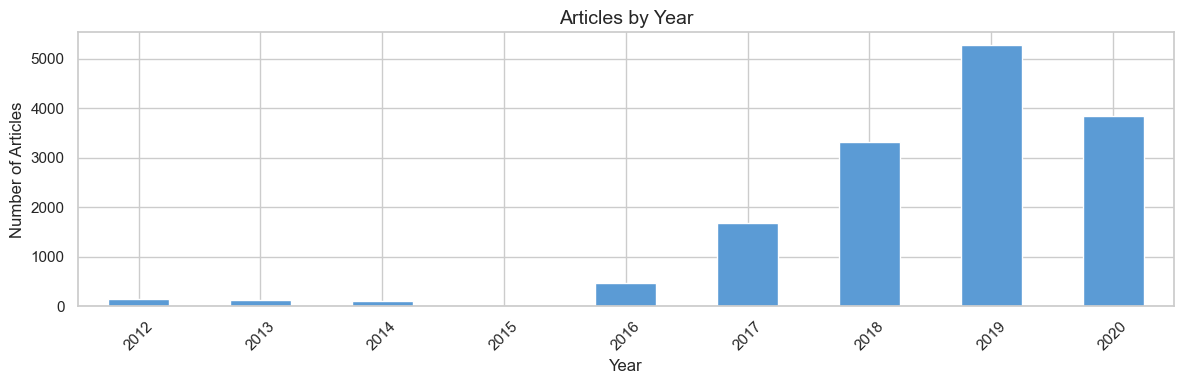

In [13]:
df['year'] = pd.to_datetime(df['date']).dt.year

fig, ax = plt.subplots(figsize=(12, 4))
df['year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#5B9BD5', edgecolor='white')
ax.set_title('Articles by Year', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig('plots/articles_by_year.png', dpi=150)
plt.show()

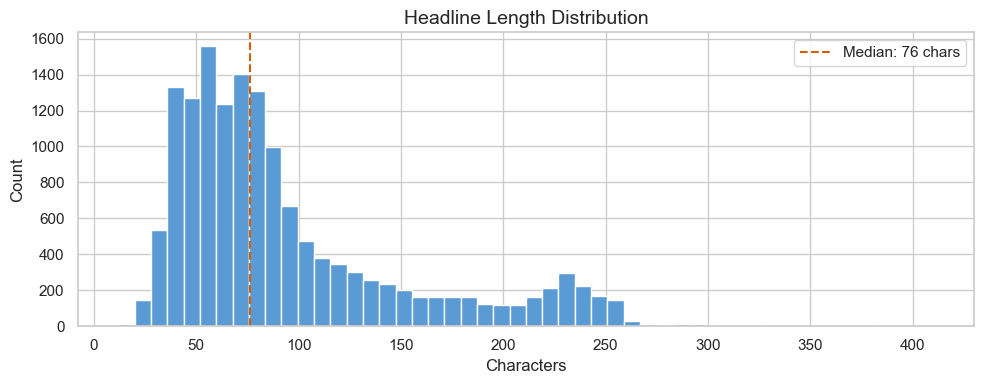

count    15000.0
mean        94.9
std         59.6
min         12.0
25%         54.0
50%         76.0
75%        114.0
max        410.0
Name: title_length, dtype: float64


In [14]:
df['title_length'] = df['article_title'].str.len()
median_len = df['title_length'].median()

fig, ax = plt.subplots(figsize=(10, 4))
df['title_length'].hist(bins=50, ax=ax, color='#5B9BD5', edgecolor='white')
ax.axvline(median_len, color='#D55E00', linestyle='--', linewidth=1.5, label=f'Median: {median_len:.0f} chars')
ax.set_title('Headline Length Distribution', fontsize=14)
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('plots/headline_length.png', dpi=150)
plt.show()
print(df['title_length'].describe().round(1))

## Section 3 — Fetch Full Price History from yfinance

All `top_tickers` are pre-screened — every ticker here is confirmed to have data for the FNSPID date range. This fetches the full history once per ticker (30 API calls total).

Results are cached in `price_cache.pkl`. The shortcut cell below skips this fetch if the cache already covers the current ticker list.

In [15]:
if os.path.exists('price_cache.pkl'):
    price_cache = pd.read_pickle('price_cache.pkl')
    missing = [t for t in top_tickers if t not in price_cache]
    if missing:
        print(f'price_cache.pkl exists but is missing {len(missing)} ticker(s): {missing}')
        print('Delete price_cache.pkl and re-run the fetch cell to rebuild for the current ticker list.')
        price_cache = None  # force re-fetch
    else:
        print(f'Loaded price_cache.pkl — all {len(top_tickers)} tickers present')
        print('Skip the fetch cell below — jump straight to label assignment.')
else:
    price_cache = None
    print('price_cache.pkl not found — run the fetch cell below.')

price_cache.pkl not found — run the fetch cell below.


In [16]:
def fetch_price_cache(tickers, date_min, date_max):
    """Fetch full price history once per ticker. Returns {ticker: Series of Close prices}."""
    cache = {}
    failed = []
    for ticker in tickers:
        try:
            hist = yf.Ticker(ticker).history(start=date_min, end=date_max)
            if hist.empty:
                print(f'  EMPTY  {ticker}')
                failed.append(ticker)
                continue
            # Handle both tz-aware and tz-naive DatetimeIndex returned by yfinance
            if hist.index.tz is not None:
                hist.index = hist.index.tz_convert(None).normalize()
            else:
                hist.index = hist.index.normalize()
            cache[ticker] = hist['Close']
        except Exception as e:
            print(f'  FAILED {ticker}: {e}')
            failed.append(ticker)
    print(f'\nCached {len(cache)} / {len(tickers)} tickers. Failed: {failed or "none"}')
    return cache


date_min = pd.to_datetime(df['date'].min()) - pd.Timedelta(days=5)
date_max = pd.to_datetime(df['date'].max()) + pd.Timedelta(days=10)

print(f'Fetching prices for {len(top_tickers)} tickers ({date_min.date()} → {date_max.date()})...')
price_cache = fetch_price_cache(top_tickers, date_min, date_max)

Fetching prices for 30 tickers (2012-01-11 → 2020-06-21)...

Cached 30 / 30 tickers. Failed: none


In [17]:
pd.to_pickle(price_cache, 'price_cache.pkl')
print(f'Saved price_cache.pkl — {len(price_cache)} tickers')

Saved price_cache.pkl — 30 tickers


In [18]:
def get_t_and_t1(ticker, date_str, cache):
    """Return (price_t, price_t1) or (None, None) if data unavailable."""
    prices = cache.get(ticker)
    if prices is None or prices.empty:
        return None, None
    date = pd.Timestamp(date_str)
    future = prices.index[prices.index >= date]
    if len(future) < 2:
        return None, None
    return float(prices[future[0]]), float(prices[future[1]])


def assign_label(pct_change, threshold):
    if pct_change > threshold * 100:
        return 'up'
    elif pct_change < -threshold * 100:
        return 'down'
    return 'neutral'


print('Assigning prices and labels...')
results = [get_t_and_t1(row['ticker'], row['date'], price_cache) for _, row in df.iterrows()]

df['price_t']    = [round(r[0], 2) if r[0] else None for r in results]
df['price_t1']   = [round(r[1], 2) if r[1] else None for r in results]
df['pct_change'] = [
    round((r[1] - r[0]) / r[0] * 100, 4) if r[0] and r[1] else None
    for r in results
]
df['label'] = [
    assign_label(p, LABEL_THRESHOLD) if pd.notna(p) else None
    for p in df['pct_change']
]

before = len(df)
df = df.dropna(subset=['label']).reset_index(drop=True)
print(f'Dropped {before - len(df):,} rows (no matching price data)')
print(f'Final dataset: {len(df):,} rows')
df[['article_id', 'date', 'ticker', 'article_title', 'price_t', 'price_t1', 'pct_change', 'label']].head(3)

Assigning prices and labels...
Dropped 15 rows (no matching price data)
Final dataset: 14,985 rows


,article_id,date,ticker,article_title,price_t,price_t1,pct_change,label
0,FNSPID_00000,2020-06-05,AEO,Shares of several retail and apparel companies...,11.14,11.21,0.6163,neutral
1,FNSPID_00001,2020-06-04,AEO,Morgan Stanley Upgrades American Eagle Outfitt...,10.58,11.14,5.2717,up
2,FNSPID_00002,2020-06-04,AEO,"Benzinga's Top Upgrades, Downgrades For June 4...",10.58,11.14,5.2717,up


## Section 5 — EDA: Labeled Data

These plots are for the June 15 checkpoint slides.

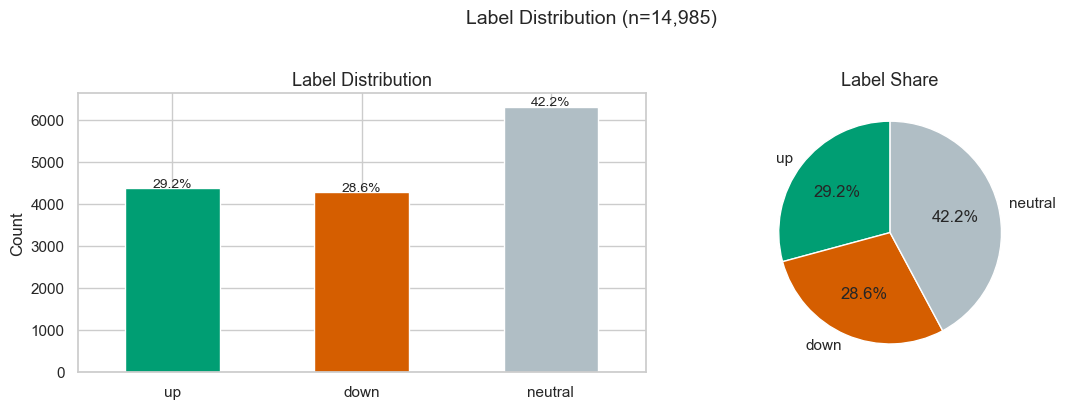

label
up         4377
down       4289
neutral    6319
Name: count, dtype: int64


In [19]:
label_counts = df['label'].value_counts().reindex(['up', 'down', 'neutral'])
colors = ['#009E73', '#D55E00', '#B0BEC5']  # teal, vermillion, blue-gray (Okabe-Ito)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Label Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['up', 'down', 'neutral'], rotation=0)
for i, v in enumerate(label_counts):
    axes[0].text(i, v + 30, f'{v / len(df) * 100:.1f}%', ha='center', fontsize=10)

label_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Label Share', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle(f'Label Distribution (n={len(df):,})', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(label_counts)

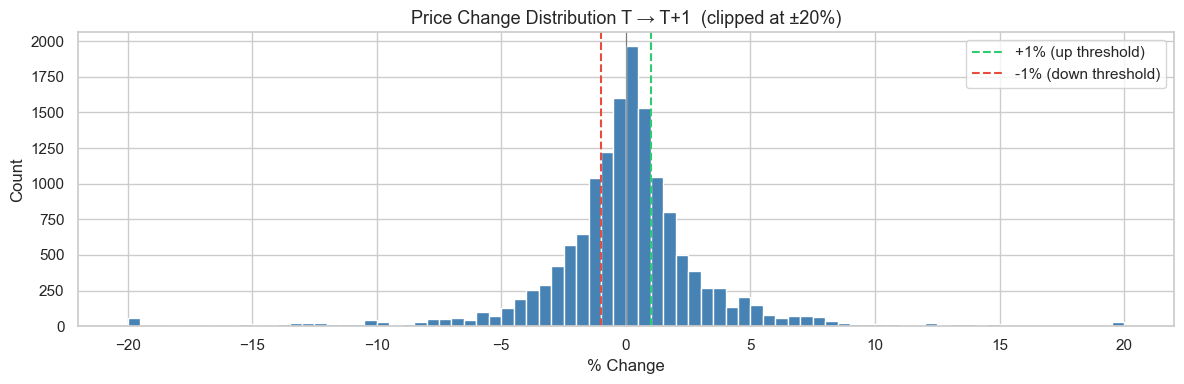

count    14985.00
mean        -0.08
std          4.07
min        -52.01
25%         -1.28
50%          0.07
75%          1.28
max         29.68
Name: pct_change, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
df['pct_change'].clip(-20, 20).hist(bins=80, ax=ax, color='steelblue', edgecolor='white')
ax.axvline( LABEL_THRESHOLD * 100, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'+{LABEL_THRESHOLD*100:.0f}% (up threshold)')
ax.axvline(-LABEL_THRESHOLD * 100, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'-{LABEL_THRESHOLD*100:.0f}% (down threshold)')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
ax.set_title('Price Change Distribution T → T+1  (clipped at ±20%)', fontsize=13)
ax.set_xlabel('% Change')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('plots/pct_change_distribution.png', dpi=150)
plt.show()
print(df['pct_change'].describe().round(2))

## Section 6 — Export

Save `processed_data.csv` as defined in `data_contracts.md` → Handoff 1.  
Column order is fixed — do not change without notifying the team.

In [21]:
OUTPUT_COLS = ['article_id', 'date', 'ticker', 'article_title', 'price_t', 'price_t1', 'pct_change', 'label']
df_output = df[OUTPUT_COLS].copy()
df_output.to_csv('processed_data.csv', index=False, encoding='utf-8')

print(f'Saved processed_data.csv')
print(f'  Rows:    {len(df_output):,}')
print(f'  Columns: {list(df_output.columns)}')
print(f'  Labels:  {df_output["label"].value_counts().to_dict()}')
df_output.head(3)

Saved processed_data.csv
  Rows:    14,985
  Columns: ['article_id', 'date', 'ticker', 'article_title', 'price_t', 'price_t1', 'pct_change', 'label']
  Labels:  {'neutral': 6319, 'up': 4377, 'down': 4289}


,article_id,date,ticker,article_title,price_t,price_t1,pct_change,label
0,FNSPID_00000,2020-06-05,AEO,Shares of several retail and apparel companies...,11.14,11.21,0.6163,neutral
1,FNSPID_00001,2020-06-04,AEO,Morgan Stanley Upgrades American Eagle Outfitt...,10.58,11.14,5.2717,up
2,FNSPID_00002,2020-06-04,AEO,"Benzinga's Top Upgrades, Downgrades For June 4...",10.58,11.14,5.2717,up


## Section 7 — Threshold Calibration

Three experiments to pick the ±% threshold empirically from our own data, rather than just copying a paper.
This section loads `processed_data.csv` directly — it can be re-run standalone without re-running the pipeline above.

**Experiments:**
1. **Threshold sweep** — class distribution (up / down / neutral %) at 0.5 %, 1 %, 1.5 %, 2 %
2. **Return distribution** — histogram of all % changes with candidate thresholds overlaid
3. **FinBERT alignment** — how well does pre-trained FinBERT sentiment agree with each threshold's labels?

Install note: experiment 3 requires `transformers` and `torch` (`pip install transformers torch`).

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

cal_df = pd.read_csv('processed_data.csv')
print(f'Loaded processed_data.csv: {len(cal_df):,} rows, {cal_df["ticker"].nunique()} tickers')
print(f'pct_change range: {cal_df["pct_change"].min():.2f}% → {cal_df["pct_change"].max():.2f}%')
cal_df[['pct_change', 'label']].describe()

Loaded processed_data.csv: 14,985 rows, 30 tickers
pct_change range: -52.01% → 29.68%


,pct_change
count,14985.000000
mean,-0.076189
std,4.074061
min,-52.013800
25%,-1.278600
50%,0.072700
75%,1.283400
max,29.684600


  ±0.5%  →  up 39.4%  down 36.8%  neutral 23.8%  (majority baseline 39.4%)
  ±1.0%  →  up 29.2%  down 28.6%  neutral 42.2%  (majority baseline 42.2%)
  ±1.5%  →  up 22.2%  down 21.7%  neutral 56.0%  (majority baseline 56.0%)
  ±2.0%  →  up 16.9%  down 17.4%  neutral 65.7%  (majority baseline 65.7%)


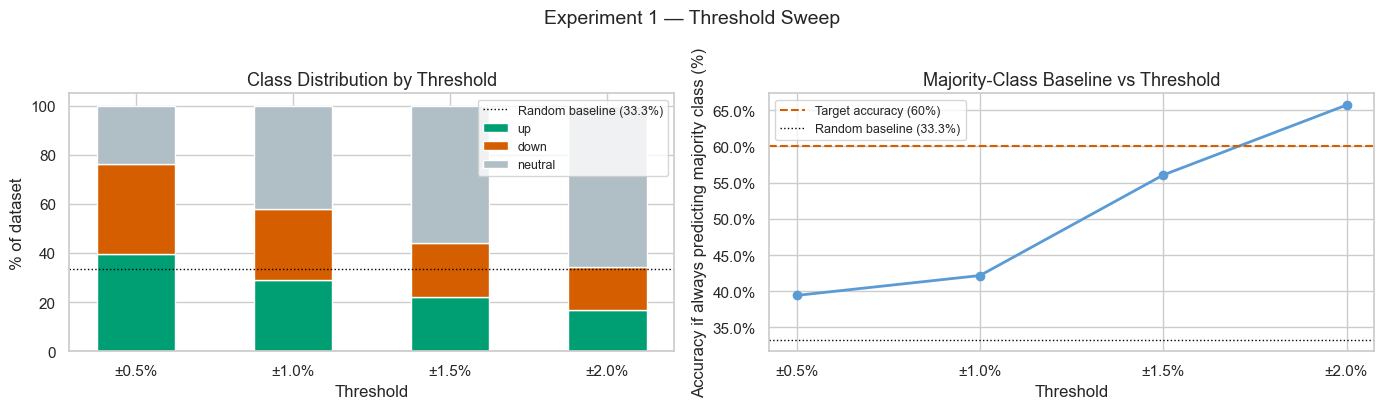

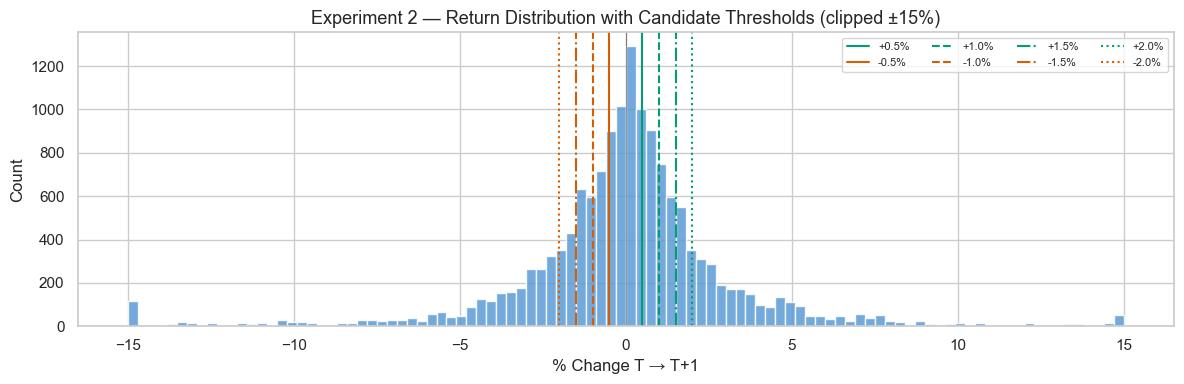

In [53]:
CANDIDATE_THRESHOLDS = [0.005, 0.01, 0.015, 0.02]  # 0.5 %, 1 %, 1.5 %, 2 %

def relabel(pct, t):
    if pct > t * 100:  return 'up'
    if pct < -t * 100: return 'down'
    return 'neutral'

# ── Experiment 1: class distribution at each threshold ──────────────────────
records = []
for t in CANDIDATE_THRESHOLDS:
    labels = cal_df['pct_change'].apply(lambda p: relabel(p, t))
    counts = labels.value_counts(normalize=True) * 100
    records.append({
        'threshold': f'±{t*100:.1f}%',
        'up':      counts.get('up',      0),
        'down':    counts.get('down',    0),
        'neutral': counts.get('neutral', 0),
        'majority_baseline': counts.max()
    })
    print(f'  ±{t*100:.1f}%  →  up {counts.get("up",0):.1f}%  down {counts.get("down",0):.1f}%  neutral {counts.get("neutral",0):.1f}%  '
          f'(majority baseline {counts.max():.1f}%)')

sweep_df = pd.DataFrame(records).set_index('threshold')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# stacked bar
colors = {'up': '#009E73', 'down': '#D55E00', 'neutral': '#B0BEC5'}
bottom = np.zeros(len(sweep_df))
for label, color in colors.items():
    axes[0].bar(sweep_df.index, sweep_df[label], bottom=bottom, label=label,
                color=color, edgecolor='white', width=0.5)
    bottom += sweep_df[label].values
axes[0].axhline(100/3, color='black', linestyle=':', linewidth=1, label='Random baseline (33.3%)')
axes[0].set_title('Class Distribution by Threshold', fontsize=13)
axes[0].set_ylabel('% of dataset')
axes[0].set_xlabel('Threshold')
axes[0].legend(loc='upper right', fontsize=9)

# majority baseline line
axes[1].plot(sweep_df.index, sweep_df['majority_baseline'], marker='o', color='#5B9BD5', linewidth=2)
axes[1].axhline(60, color='#D55E00', linestyle='--', linewidth=1.5, label='Target accuracy (60%)')
axes[1].axhline(100/3, color='black', linestyle=':', linewidth=1, label='Random baseline (33.3%)')
axes[1].set_title('Majority-Class Baseline vs Threshold', fontsize=13)
axes[1].set_ylabel('Accuracy if always predicting majority class (%)')
axes[1].set_xlabel('Threshold')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle('Experiment 1 — Threshold Sweep', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Experiment 2: return distribution with threshold lines overlaid ──────────
fig, ax = plt.subplots(figsize=(12, 4))
clipped = cal_df['pct_change'].clip(-15, 15)
ax.hist(clipped, bins=100, color='#5B9BD5', edgecolor='white', alpha=0.85)

line_styles = ['-', '--', '-.', ':']
for (t, ls) in zip(CANDIDATE_THRESHOLDS, line_styles):
    ax.axvline( t * 100, color='#009E73', linestyle=ls, linewidth=1.5, label=f'+{t*100:.1f}%')
    ax.axvline(-t * 100, color='#D55E00', linestyle=ls, linewidth=1.5, label=f'-{t*100:.1f}%')
ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_title('Experiment 2 — Return Distribution with Candidate Thresholds (clipped ±15%)', fontsize=13)
ax.set_xlabel('% Change T → T+1')
ax.set_ylabel('Count')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig('plots/threshold_distribution.png', dpi=150)
plt.show()

In [ ]:
# Experiment 3 (FinBERT alignment) — skipped for now due to transformers 5.x compatibility.
# Run experiments 1 and 2 above; revisit this cell when the library issue is resolved.
print('Experiment 3 skipped.')

### Threshold Decision

Fill in after running the three experiments above.

| Criterion | Best threshold | Notes |
|---|---|---|
| Class balance (Exp. 1) | | |
| Distribution shape (Exp. 2) | | |
| FinBERT alignment (Exp. 3) | | |
| **Chosen threshold** | **±1%** | |

**Justification:** We set `LABEL_THRESHOLD = 0.01` (±1%) because [fill in based on experiment results].
This is consistent with Jiang & Zeng (2023) and the large-cap tier in BioFinBERT (2024), and is empirically supported by our own data as shown above.